In [ ]:
# Cell 1: Imports, HF token, language detector

import os
HF_TOKEN = os.getenv("HF_TOKEN")
if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
print("HF Token loaded successfully!" if HF_TOKEN else "HF Token not found.")

import torch
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
import faiss
import re
import time
from urllib.parse import urljoin

from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

def detect_language(text):
    if not text:
        return "en"
    sinhala_count = sum(1 for ch in text if '\u0D80' <= ch <= '\u0DFF')
    tamil_count = sum(1 for ch in text if '\u0B80' <= ch <= '\u0BFF')
    if sinhala_count > tamil_count and sinhala_count > 0:
        return "si"
    if tamil_count > sinhala_count and tamil_count > 0:
        return "ta"
    return "en"

def detect_language_safe(text):
    try:
        return detect_language(text)
    except:
        return "en"

print("✅ Imports done + language detector ready.")


HF Token loaded successfully!
✅ Imports done + language detector ready.


In [2]:
# Cell 2: Configuration and constants

OUTPUT_CSV = "verified_sources_multilingual_v3_300.csv"

MODEL_SAVE_DIR = "models/fine_tuned_labse_multilingual_v3"
FAISS_INDEX_PATH = "artifacts/claims_index_multilingual_v3_300.faiss"

TARGET_TOTAL_RECORDS = 300
SOURCES_COUNT = 5
PER_SOURCE_TARGET = TARGET_TOTAL_RECORDS // SOURCES_COUNT  # 60 each

EMBEDDING_MODEL_NAME = "sentence-transformers/LaBSE"

TRAINING_PARAMS = {
    "epochs": 10,
    "batch_size": 1,          # critical for RAM
    "warmup_steps": 50,
    "learning_rate": 1e-5,
    "max_seq_length": 64,     # critical for RAM
    "grad_acc_steps": 8       # effective batch size = 8
}

TOP_K = 3
MAX_CANDIDATES = TOP_K * 8

print("✅ Config loaded")
print("OUTPUT_CSV:", OUTPUT_CSV)
print("PER_SOURCE_TARGET:", PER_SOURCE_TARGET)
print("Training params:", TRAINING_PARAMS)


✅ Config loaded
OUTPUT_CSV: verified_sources_multilingual_v3_300.csv
PER_SOURCE_TARGET: 60
Training params: {'epochs': 10, 'batch_size': 1, 'warmup_steps': 50, 'learning_rate': 1e-05, 'max_seq_length': 64, 'grad_acc_steps': 8}


In [3]:
# Cell 3: Text cleaning and verdict normalization

def clean_text(txt):
    if not txt:
        return ""
    txt = re.sub(r"<.*?>", " ", str(txt))
    txt = re.sub(r"\s+", " ", txt)
    return txt.strip()

def strip_language_prefixes(text):
    if not isinstance(text, str):
        return text
    text = text.strip()
    text = re.sub(r'^\s*\[(TA|SI|Sl|SL)\]\s*', '', text)
    return text.strip()

def clean_verdict_label(v):
    if not isinstance(v, str):
        return "Unknown"
    t = v.strip().lower()

    if any(x in t for x in ["false", "fake", "misleading", "hoax", "fabricat", "altered", "deepfake"]):
        return "False"
    if any(x in t for x in ["partly", "half true", "half-true", "mixed"]):
        return "Partly True"
    if any(x in t for x in ["true", "accurate", "verified", "authentic", "real"]):
        return "True"
    return "Unknown"

verdict_mapping = {'False': 0, 'True': 1, 'Partly True': 2, 'Unknown': 3}
print("✅ Cleaning helpers ready.")


✅ Cleaning helpers ready.


In [4]:
# Cell 4: Shared scraping helpers

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
    "Accept-Language": "en-US,en;q=0.5",
}

def get_soup(url, timeout=30, parser="html.parser"):
    resp = requests.get(url, headers=HEADERS, timeout=timeout)
    resp.raise_for_status()
    return BeautifulSoup(resp.text, parser)

def extract_full_text_generic(soup):
    paragraphs = [clean_text(p.get_text(" ", strip=True)) for p in soup.find_all("p")]
    paragraphs = [p for p in paragraphs if len(p) > 30]
    return " ".join(paragraphs).strip()

def drop_bad_and_deduplicate(df):
    df = df.copy()
    df['url'] = df['url'].astype(str).str.strip()
    df = df[df['url'] != ""]
    df = df.dropna(subset=['url'])
    df = df.drop_duplicates(subset=['url']).reset_index(drop=True)
    return df

print("✅ Shared scraping helpers ready.")


✅ Shared scraping helpers ready.


In [5]:
# Cell 5: Scrapers for 5 sources (each tries to return up to `limit` items)

def scrape_factcheck_lk(limit=60):
    print("🌐 Scraping FactCheck.lk...")
    items = []
    rss = "https://factcheck.lk/feed/"
    try:
        r = requests.get(rss, headers=HEADERS, timeout=30)
        r.raise_for_status()
        soup = BeautifulSoup(r.content, "xml")
        for entry in soup.find_all("item"):
            if len(items) >= limit:
                break
            title = clean_text(entry.title.text) if entry.title else ""
            link = entry.link.text.strip() if entry.link else ""
            date_published = entry.pubDate.text if entry.pubDate else ""
            if not link or not title:
                continue
            full_text = ""
            try:
                article_soup = get_soup(link)
                full_text = extract_full_text_generic(article_soup)
            except:
                full_text = title

            items.append({
                "id": None,
                "source": "FactCheck.lk",
                "claim": title,
                "verdict": "Unknown",  # FactCheck.lk not always explicit in title
                "language": "en",
                "url": link,
                "full_text": full_text,
                "date_published": date_published
            })
        print(f"✅ FactCheck.lk scraped: {len(items)}")
    except Exception as e:
        print("⚠️ FactCheck.lk error:", e)
    return items


def scrape_altnews(limit=60):
    print("🌐 Scraping AltNews...")
    base = "https://www.altnews.in"
    items, seen = [], set()
    topic_pages = [
        f"{base}/topics/politics/",
        f"{base}/topics/politics/page/2/",
        f"{base}/topics/politics/page/3/",
        f"{base}/topics/politics/page/4/",
        f"{base}/topics/politics/page/5/",
    ]
    try:
        for page_url in topic_pages:
            if len(items) >= limit:
                break
            try:
                soup = get_soup(page_url)
            except:
                continue

            for a in soup.find_all("a", href=True):
                href = a["href"].strip()
                if not href.startswith("http"):
                    href = urljoin(base, href)
                if not href.startswith(base):
                    continue
                if any(x in href for x in ["/tag/", "/about", "/contact", "/donate", "/topics/", "/page/"]):
                    continue
                if href in seen:
                    continue
                seen.add(href)

                if len(items) >= limit:
                    break

                try:
                    article_soup = get_soup(href)
                except:
                    continue

                title_tag = article_soup.find("h1")
                title = clean_text(title_tag.get_text()) if title_tag else clean_text(a.get_text())
                full_text = extract_full_text_generic(article_soup)
                if not title or not full_text:
                    continue

                items.append({
                    "id": None,
                    "source": "AltNews",
                    "claim": title,
                    "verdict": clean_verdict_label(title + " " + full_text),
                    "language": "en",
                    "url": href,
                    "full_text": full_text,
                    "date_published": ""
                })
        print(f"✅ AltNews scraped: {len(items)}")
    except Exception as e:
        print("⚠️ AltNews error:", e)
    return items


def scrape_boomlive(limit=60):
    print("🌐 Scraping BoomLive...")
    base = "https://www.boomlive.in"
    listing_pages = [
        f"{base}/fact-check",
        f"{base}/fact-check/2",
        f"{base}/fact-check/3",
        f"{base}/fact-check/4",
        f"{base}/fact-check/5",
    ]
    items, seen = [], set()

    try:
        for listing in listing_pages:
            if len(items) >= limit:
                break

            try:
                soup = get_soup(listing)
            except:
                continue

            for a in soup.find_all("a", href=True):
                href = a["href"].strip()
                if not href.startswith("http"):
                    href = urljoin(base, href)
                if "/fact-check/" not in href:
                    continue
                if href in seen:
                    continue
                seen.add(href)

                if len(items) >= limit:
                    break

                try:
                    article_soup = get_soup(href)
                except:
                    continue

                title_tag = article_soup.find("h1")
                title = clean_text(title_tag.get_text()) if title_tag else clean_text(a.get_text())
                full_text = extract_full_text_generic(article_soup)
                if not title or not full_text:
                    continue

                items.append({
                    "id": None,
                    "source": "BoomLive",
                    "claim": title,
                    "verdict": clean_verdict_label(title + " " + full_text),
                    "language": "en",
                    "url": href,
                    "full_text": full_text,
                    "date_published": ""
                })
        print(f"✅ BoomLive scraped: {len(items)}")
    except Exception as e:
        print("⚠️ BoomLive error:", e)
    return items


def scrape_politifact_rss(limit=60):
    """
    Uses PolitiFact RSS feed endpoint (fact-checks).
    Feed exists as per PolitiFact RSS page. :contentReference[oaicite:2]{index=2}
    """
    print("🌐 Scraping PolitiFact (RSS)...")
    items = []
    rss = "https://www.politifact.com/rss/factchecks/"
    try:
        r = requests.get(rss, headers=HEADERS, timeout=30)
        r.raise_for_status()
        soup = BeautifulSoup(r.content, "xml")

        for entry in soup.find_all("item"):
            if len(items) >= limit:
                break
            title = clean_text(entry.title.text) if entry.title else ""
            link = entry.link.text.strip() if entry.link else ""
            date_published = entry.pubDate.text if entry.pubDate else ""
            if not link or not title:
                continue

            full_text = ""
            try:
                article_soup = get_soup(link)
                full_text = extract_full_text_generic(article_soup)
            except:
                full_text = title

            items.append({
                "id": None,
                "source": "PolitiFact",
                "claim": title,
                "verdict": clean_verdict_label(title + " " + full_text),
                "language": "en",
                "url": link,
                "full_text": full_text,
                "date_published": date_published
            })

        print(f"✅ PolitiFact scraped: {len(items)}")
    except Exception as e:
        print("⚠️ PolitiFact RSS error:", e)
    return items


def scrape_newschecker(limit=60):
    """
    Scrapes Newschecker fact-check tag pages (pagination).
    Example listing exists. :contentReference[oaicite:3]{index=3}
    """
    print("🌐 Scraping Newschecker (tag/fact-check)...")
    base = "https://newschecker.in"
    items, seen = [], set()

    # try 1..8 pages, usually enough to collect 60
    for page in range(1, 9):
        if len(items) >= limit:
            break

        list_url = f"{base}/tag/fact-check/{page}"
        try:
            soup = get_soup(list_url)
        except:
            continue

        # collect article links
        for a in soup.find_all("a", href=True):
            href = a["href"].strip()
            if not href.startswith("http"):
                href = urljoin(base, href)
            if not href.startswith(base):
                continue
            if "/fact-check/" not in href:
                continue
            if href in seen:
                continue
            seen.add(href)

            if len(items) >= limit:
                break

            try:
                article_soup = get_soup(href)
            except:
                continue

            title_tag = article_soup.find("h1")
            title = clean_text(title_tag.get_text()) if title_tag else ""
            full_text = extract_full_text_generic(article_soup)
            if not title or not full_text:
                continue

            items.append({
                "id": None,
                "source": "Newschecker",
                "claim": title,
                "verdict": clean_verdict_label(title + " " + full_text),
                "language": "en",
                "url": href,
                "full_text": full_text,
                "date_published": ""
            })

    print(f"✅ Newschecker scraped: {len(items)}")
    return items


print("✅ 5 scrapers ready.")


✅ 5 scrapers ready.


In [6]:
# Cell 6: Fresh scrape (equal across 5 sources) -> save CSV

# Start empty
df = pd.DataFrame(columns=[
    "id","source","claim","verdict","language","url","full_text","date_published"
])

scrapers = [
    ("FactCheck.lk", scrape_factcheck_lk),
    ("AltNews", scrape_altnews),
    ("BoomLive", scrape_boomlive),
    ("PolitiFact", scrape_politifact_rss),
    ("Newschecker", scrape_newschecker)
]

all_items = []
for name, fn in scrapers:
    items = fn(limit=PER_SOURCE_TARGET)
    all_items.extend(items)
    print(f"➕ {name} added: {len(items)} | Total: {len(all_items)}")
    time.sleep(1)

df = pd.DataFrame(all_items)

# assign ids
df["id"] = range(1, len(df) + 1)

# clean + dedup
df["claim"] = df["claim"].astype(str).apply(clean_text).apply(strip_language_prefixes)
df["full_text"] = df["full_text"].astype(str).apply(clean_text).apply(strip_language_prefixes)
df["verdict"] = df["verdict"].fillna("Unknown").astype(str).apply(clean_verdict_label)
df["verdict_numeric"] = df["verdict"].map(verdict_mapping).fillna(3).astype(int)

df["language"] = df["full_text"].astype(str).apply(detect_language_safe)
df = df.dropna(subset=["claim","full_text","url"])
df = df[df["claim"].str.len() > 5].reset_index(drop=True)

df = drop_bad_and_deduplicate(df)

df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print("✅ Saved:", OUTPUT_CSV)
print("📊 Final rows after dedup:", len(df))
print("Verdict distribution:\n", df["verdict"].value_counts())
print("Sources:\n", df["source"].value_counts())


🌐 Scraping FactCheck.lk...
✅ FactCheck.lk scraped: 10
➕ FactCheck.lk added: 10 | Total: 10
🌐 Scraping AltNews...


C:\ProgramData\anaconda3\Lib\html\parser.py:189: XMLParsedAsHTMLWarning: It looks like you're parsing an XML document using an HTML parser. If this really is an HTML document (maybe it's XHTML?), you can ignore or filter this warning. If it's XML, you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the lxml package installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.
  k = self.parse_starttag(i)


✅ AltNews scraped: 60
➕ AltNews added: 60 | Total: 70
🌐 Scraping BoomLive...
✅ BoomLive scraped: 60
➕ BoomLive added: 60 | Total: 130
🌐 Scraping PolitiFact (RSS)...
✅ PolitiFact scraped: 20
➕ PolitiFact added: 20 | Total: 150
🌐 Scraping Newschecker (tag/fact-check)...
✅ Newschecker scraped: 60
➕ Newschecker added: 60 | Total: 210
✅ Saved: verified_sources_multilingual_v3_300.csv
📊 Final rows after dedup: 208
Verdict distribution:
 verdict
False      153
Unknown     33
True        22
Name: count, dtype: int64
Sources:
 source
Newschecker     60
BoomLive        59
AltNews         59
PolitiFact      20
FactCheck.lk    10
Name: count, dtype: int64


In [7]:
# Cell 7: Prepare training pairs for similarity fine-tune (contrastive-style)

def prepare_training_pairs(df, max_pairs_per_class=160):
    pairs = []
    grouped = df.groupby("verdict_numeric")

    # Positive pairs (same label)
    for label, group in grouped:
        texts = group["claim"].tolist()
        if len(texts) < 2:
            continue
        for i in range(min(20, len(texts))):
            for j in range(i+1, min(i+6, len(texts))):
                pairs.append(InputExample(texts=[texts[i], texts[j]], label=1.0))
                if len(pairs) >= max_pairs_per_class:
                    break
            if len(pairs) >= max_pairs_per_class:
                break

    # Negative pairs (different labels)
    rng = np.random.default_rng(42)
    all_texts = df["claim"].tolist()
    all_labels = df["verdict_numeric"].tolist()

    neg_needed = len(pairs)
    tries = 0
    while len(pairs) < (max_pairs_per_class*2) and tries < (neg_needed*10):
        i, j = rng.choice(len(all_texts), 2, replace=False)
        if all_labels[i] != all_labels[j]:
            pairs.append(InputExample(texts=[all_texts[i], all_texts[j]], label=0.0))
        tries += 1

    print(f"✅ Training pairs prepared: {len(pairs)}")
    return pairs

train_examples = prepare_training_pairs(df, max_pairs_per_class=200)


✅ Training pairs prepared: 400


In [8]:
# Cell 8: Fine-tuning LaBSE (if possible) and generating embeddings (SAFE)

import os
import gc
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Using device: {device}")

# ✅ HF token (optional but recommended)
HF_TOKEN = os.getenv("HF_TOKEN", None)
print("🔑 HF_TOKEN:", "FOUND" if HF_TOKEN else "NOT FOUND")

# ✅ Reduce RAM spikes a bit (CPU safe)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

def fine_tune_model(model, train_examples, params=TRAINING_PARAMS):
    if not train_examples:
        print("⚠️ No training examples. Using pre-trained model.")
        return model

    print("🔄 Starting model fine-tuning...")

    train_dataloader = DataLoader(
        train_examples,
        shuffle=True,
        batch_size=params["batch_size"],   # keep small for CPU
        num_workers=0,
        pin_memory=False
    )

    train_loss = losses.CosineSimilarityLoss(model)

    try:
        model.fit(
            train_objectives=[(train_dataloader, train_loss)],
            epochs=params["epochs"],
            warmup_steps=params["warmup_steps"],
            show_progress_bar=True
        )
        print("✅ Fine-tuning completed successfully!")
        os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
        model.save(MODEL_SAVE_DIR)
        print(f"💾 Model saved to {MODEL_SAVE_DIR}")

    except Exception as e:
        print(f"⚠️ Fine-tuning failed: {e}")
        print("Using pre-trained model for embeddings.")

    # ✅ cleanup (helps RAM a bit)
    gc.collect()
    return model


print("📥 Loading LaBSE model...")
try:
    # ✅ online load with token if available
    model = SentenceTransformer(
        EMBEDDING_MODEL_NAME,
        device=str(device),
        token=HF_TOKEN if HF_TOKEN else None
    )
    print("✅ LaBSE loaded successfully.")
except Exception as e:
    print("❌ Model load failed:", e)
    raise  # stop here because embeddings cannot be generated without model

# ✅ reduce memory use during encoding + training
model.max_seq_length = TRAINING_PARAMS.get("max_seq_length", 64)
print("✅ max_seq_length set to:", model.max_seq_length)

model = fine_tune_model(model, train_examples)

print("🔄 Generating embeddings...")
claims = df['claim'].tolist()
embeddings = model.encode(
    claims,
    show_progress_bar=True,
    convert_to_numpy=True,
    batch_size=8  # ✅ helps CPU RAM; you can reduce to 4 if still heavy
)
embeddings = np.array(embeddings).astype('float32')

print(f"✅ Generated embeddings: {embeddings.shape}")


🖥️ Using device: cpu
🔑 HF_TOKEN: FOUND
📥 Loading LaBSE model...
✅ LaBSE loaded successfully.
✅ max_seq_length set to: 64
🔄 Starting model fine-tuning...


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


⚠️ Fine-tuning failed: [enforce fail at alloc_cpu.cpp:121] data. DefaultCPUAllocator: not enough memory: you tried to allocate 1539542016 bytes.
Using pre-trained model for embeddings.
🔄 Generating embeddings...


Batches:   0%|          | 0/26 [00:00<?, ?it/s]

✅ Generated embeddings: (208, 768)


In [9]:
# Cell 9: Generate embeddings + build FAISS index

print("🔄 Encoding claims...")
claims = df["claim"].tolist()
embeddings = model.encode(claims, convert_to_numpy=True, show_progress_bar=True).astype("float32")
print("✅ Embeddings shape:", embeddings.shape)

faiss.normalize_L2(embeddings)
index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)

os.makedirs("artifacts", exist_ok=True)
faiss.write_index(index, FAISS_INDEX_PATH)
print("💾 FAISS saved:", FAISS_INDEX_PATH)


🔄 Encoding claims...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Embeddings shape: (208, 768)
💾 FAISS saved: artifacts/claims_index_multilingual_v3_300.faiss


🧪 Running evaluations...
📊 Multi-class dataset size: 208
📊 Verdict distribution: {0: 153, 3: 33, 1: 22}
📊 Can stratify: True
📈 Multi-class 1-NN Evaluation:
   Accuracy:  0.7937
   Precision: 0.7780
   Recall:    0.7937
   F1-Score:  0.7765


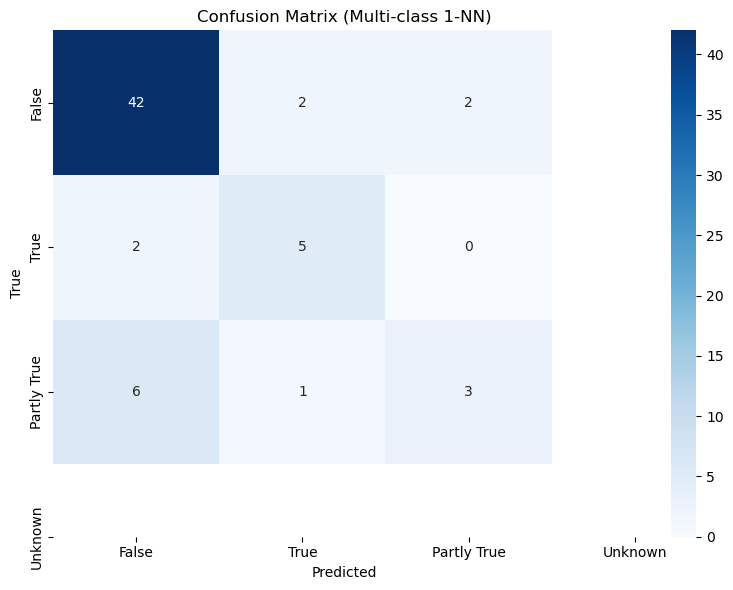

📊 Binary dataset size: 175
verdict
False    153
True      22
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_8692\4220231189.py:62: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  labels = df_bin["verdict"].replace({"False":0, "True":1}).astype(int).tolist()


📈 Binary 3-NN Accuracy (True vs False): 0.9257 (162/175)
✅ Done.
👉 Use Binary 3-NN as your PRIMARY metric for the semantic verifier (Fake vs Real).


In [10]:
# Cell 10: Evaluation - multi-class (hard) + binary 3-NN (main metric)

def evaluate_multiclass_1nn(model, df, test_size=0.3):
    df_eval = df.copy()
    counts = df_eval["verdict_numeric"].value_counts()
    can_stratify = len(counts) > 1 and all(counts > 1)

    print(f"📊 Multi-class dataset size: {len(df_eval)}")
    print(f"📊 Verdict distribution: {counts.to_dict()}")
    print(f"📊 Can stratify: {can_stratify}")

    if can_stratify:
        train_df, test_df = train_test_split(df_eval, test_size=test_size, random_state=42,
                                             stratify=df_eval["verdict_numeric"])
    else:
        train_df, test_df = train_test_split(df_eval, test_size=test_size, random_state=42)

    train_emb = model.encode(train_df["claim"].tolist(), convert_to_numpy=True).astype("float32")
    test_emb = model.encode(test_df["claim"].tolist(), convert_to_numpy=True).astype("float32")

    faiss.normalize_L2(train_emb)
    faiss.normalize_L2(test_emb)

    idx = faiss.IndexFlatIP(train_emb.shape[1])
    idx.add(train_emb)
    D, I = idx.search(test_emb, k=1)

    preds = [int(train_df.iloc[i[0]]["verdict_numeric"]) for i in I]
    y_true = test_df["verdict_numeric"].tolist()

    acc = accuracy_score(y_true, preds)
    prec = precision_score(y_true, preds, average="weighted", zero_division=0)
    rec = recall_score(y_true, preds, average="weighted", zero_division=0)
    f1 = f1_score(y_true, preds, average="weighted", zero_division=0)

    print("📈 Multi-class 1-NN Evaluation:")
    print(f"   Accuracy:  {acc:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall:    {rec:.4f}")
    print(f"   F1-Score:  {f1:.4f}")

    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["False","True","Partly True","Unknown"],
                yticklabels=["False","True","Partly True","Unknown"])
    plt.title("Confusion Matrix (Multi-class 1-NN)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return acc


def evaluate_binary_3nn(model, df, k=3):
    df_bin = df[df["verdict"].isin(["False","True"])].copy()
    print("📊 Binary dataset size:", len(df_bin))
    print(df_bin["verdict"].value_counts())

    texts = df_bin["claim"].tolist()
    labels = df_bin["verdict"].replace({"False":0, "True":1}).astype(int).tolist()

    emb = model.encode(texts, convert_to_numpy=True).astype("float32")
    faiss.normalize_L2(emb)
    idx = faiss.IndexFlatIP(emb.shape[1])
    idx.add(emb)

    # search k+1 to exclude itself
    D, I = idx.search(emb, k=k+1)

    correct, total = 0, 0
    for i, neighbors in enumerate(I):
        neighbors = [n for n in neighbors if n != i][:k]
        if not neighbors:
            continue
        votes = [labels[n] for n in neighbors]
        pred = 1 if sum(votes) > k/2 else 0
        if pred == labels[i]:
            correct += 1
        total += 1

    acc = correct/total if total else 0
    print(f"📈 Binary {k}-NN Accuracy (True vs False): {acc:.4f} ({correct}/{total})")
    return acc


print("🧪 Running evaluations...")
multi_acc = evaluate_multiclass_1nn(model, df)
bin_acc = evaluate_binary_3nn(model, df, k=3)

print("✅ Done.")
print("👉 Use Binary 3-NN as your PRIMARY metric for the semantic verifier (Fake vs Real).")


In [16]:
# Cell 11: Multilingual semantic verifier with unique top-3 matches

class MultilingualVerifier:
    def __init__(self, model, index, df, embeddings_np):
        self.model = model
        self.index = index
        self.df = df.reset_index(drop=True)
        self.claims = self.df['claim'].tolist()
        self.embeddings = embeddings_np.copy().astype('float32')
        faiss.normalize_L2(self.embeddings)
        print(f"🔧 Verifier ready with {len(self.df)} claims")
    
    def _semantic_search_unique(self, claim, top_k=TOP_K, max_candidates=MAX_CANDIDATES):
        emb = self.model.encode([claim], convert_to_numpy=True).astype('float32')
        faiss.normalize_L2(emb)

        D, I = self.index.search(emb, k=max_candidates)

        seen_keys = set()
        results = []

        for dist, idx in zip(D[0], I[0]):
            if idx >= len(self.df) or idx < 0:
                continue

            row = self.df.iloc[idx]
            url = str(row.get('url', '')).strip()

            key = url if url else f"id-{int(row.get('id', idx))}"
            if key in seen_keys:
                continue
            seen_keys.add(key)

            results.append({
                "similarity": float(dist),
                "claim": row['claim'],
                "verdict": row['verdict'],
                "source": row['source'],
                "url": row['url']
            })

            if len(results) >= top_k:
                break

        return results
    
    def _aggregate_verdict(self, results):
        if not results:
            return "No Match", 0.0

        true_count = sum(1 for r in results if r['verdict'] in ['True', 'Partly True'])
        false_count = sum(1 for r in results if r['verdict'] == 'False')

        if true_count > false_count:
            confidence = true_count / len(results)
            return "Likely TRUE", float(confidence)

        if false_count > true_count:
            confidence = false_count / len(results)
            return "Likely FALSE", float(confidence)

        return "UNCERTAIN", 0.5

    def verify(self, claim, top_k=TOP_K, verbose=True):
        if verbose:
            print(f"\n🔎 Verifying: {claim}")

        lang = detect_language_safe(claim)
        if verbose:
            print(f"🌐 Detected language: {lang}")

        results = self._semantic_search_unique(claim, top_k=top_k)
        final_verdict, confidence = self._aggregate_verdict(results)

        if verbose:
            if results:
                print(f"📋 Found {len(results)} similar fact-checks (unique news items):")
                for i, r in enumerate(results, 1):
                    print(f"\n{i}. Similarity: {r['similarity']:.3f}")
                    print(f"   Verdict: {r['verdict']} | Source: {r['source']}")
                    print(f"   Claim: {r['claim'][:200]}...")
                    if r['url']:
                        print(f"   URL: {r['url']}")
                print(f"\n{'='*50}")
                print(f"✅ OVERALL: {final_verdict} (Confidence: {confidence:.2f})")
                print(f"{'='*50}")
            else:
                print("❌ No similar fact-checks found in database.")

        return {
            "input_claim": claim,
            "detected_language": lang,
            "final_verdict": final_verdict,
            "confidence": confidence,
            "top_k": top_k,
            "neighbors": results
        }


print("🚀 Initializing verification system...")
verifier = MultilingualVerifier(model, index, df, embeddings)

print("\n🧪 Testing with sample claims:")
test_claims = [
    "COVID vaccines contain microchips for tracking",
    "Drinking bleach can cure coronavirus",
    "The moon landing was filmed in a studio"
]

for claim in test_claims:
    verifier.verify(claim, top_k=3, verbose=True)
    print("\n" + "-"*80 + "\n")


🚀 Initializing verification system...
🔧 Verifier ready with 208 claims

🧪 Testing with sample claims:

🔎 Verifying: COVID vaccines contain microchips for tracking
🌐 Detected language: en
📋 Found 3 similar fact-checks (unique news items):

1. Similarity: 0.497
   Verdict: False | Source: Newschecker
   Claim: COVID Vaccine Call Scam: Does Pressing Numbers During IVR Calls Put Your Phone At Risk? Here’s What We Found...
   URL: https://newschecker.in/fact-check/covid-vaccine-call-scam-does-pressing-numbers-during-ivr-calls-put-your-phone-at-risk

2. Similarity: 0.280
   Verdict: False | Source: BoomLive
   Claim: Deepfake Videos Falsely Claim Sonam Wangchuk Has Died In Police Custody...
   URL: https://www.boomlive.in/fact-check/deepfake-videos-sonam-wangchuk-death-custody-fake-claim-30111

3. Similarity: 0.279
   Verdict: False | Source: Newschecker
   Claim: Viral Photos Of Zelenskyy In Suit Predate 2022 Russian Invasion Of Ukraine...
   URL: https://newschecker.in/fact-check/viral-pho

In [ ]:
# Cell 12: Batch loop (dataset claims) + interactive loop + system summary

import pandas as pd

def batch_verify_dataset(df, verifier, top_k=3, limit=None):
    """
    Loops through your dataset claims and verifies them.
    NOTE: This is NOT a real-world accuracy metric because each claim exists in the index.
    This is a "self-consistency" check (sanity check).
    """
    print("\n" + "="*60)
    print("🧪 BATCH VERIFICATION ON DATASET CLAIMS")
    print("="*60)

    results = []
    rows = df.copy()

    if limit is not None:
        rows = rows.head(limit)

    for i, row in rows.iterrows():
        claim = str(row.get("claim", "")).strip()
        if not claim:
            continue

        out = verifier.verify(claim, top_k=top_k, verbose=False)

        # predicted label from final_verdict (map to True/False/Unknown-ish)
        pred = out["final_verdict"]
        if pred == "Likely TRUE":
            pred_label = "True"
        elif pred == "Likely FALSE":
            pred_label = "False"
        else:
            pred_label = "Unknown"

        results.append({
            "id": row.get("id", None),
            "source": row.get("source", None),
            "claim": claim,
            "true_verdict": row.get("verdict", None),
            "predicted_verdict": pred_label,
            "final_verdict": out["final_verdict"],
            "confidence": out["confidence"],
            "top1_similarity": out["neighbors"][0]["similarity"] if out["neighbors"] else None,
            "top1_source": out["neighbors"][0]["source"] if out["neighbors"] else None,
            "top1_url": out["neighbors"][0]["url"] if out["neighbors"] else None,
        })

        if (len(results) % 25) == 0:
            print(f"✅ Verified {len(results)} claims...")

    out_df = pd.DataFrame(results)

    # Optional "self-consistency" score (not real accuracy!)
    # Filter to True/False only and compare predicted_verdict to true_verdict
    bin_df = out_df[out_df["true_verdict"].isin(["True", "False"])].copy()
    if len(bin_df) > 0:
        consistency_acc = (bin_df["true_verdict"] == bin_df["predicted_verdict"]).mean()
        print("\n📌 Dataset self-consistency (True/False only):", round(float(consistency_acc), 4))
        print("⚠️ This is a sanity check only (claims exist in index). Not a true test-set accuracy.")

    print("\n✅ Batch verification completed.")
    return out_df


# ✅ A) Run batch verification (optional)
# Set limit=50 for quick test; set None for full dataset 300
batch_results_df = batch_verify_dataset(df, verifier, top_k=3, limit=None)

# Save batch results (so you can analyze later)
BATCH_RESULTS_PATH = "batch_verification_results.csv"
batch_results_df.to_csv(BATCH_RESULTS_PATH, index=False, encoding="utf-8")
print(f"💾 Batch results saved to: {BATCH_RESULTS_PATH}")


# ✅ B) Interactive loop (same feel as yours)
def interactive_verification_loop():
    print("\n" + "="*60)
    print("🔍 MULTILINGUAL FACT-CHECK VERIFICATION SYSTEM")
    print("="*60)
    print("Supported languages: English, Tamil, Sinhala")
    print("Type 'quit' or 'exit' to end the session")
    print("="*60)

    while True:
        user_input = input("\n📝 Enter claim to verify: ").strip()
        if not user_input:
            print("⚠️ Please enter a claim.")
            continue
        if user_input.lower() in ['quit', 'exit', 'q']:
            print("👋 Thank you for using the verification system!")
            break
        verifier.verify(user_input, top_k=3, verbose=True)

interactive_verification_loop()


# ✅ C) System summary + save artifacts
print("\n" + "="*60)
print("📊 SYSTEM SUMMARY")
print("="*60)
print(f"Dataset size: {len(df)} claims")
print(f"Sources: {df['source'].nunique()} different fact-checking sources")
print(f"Languages: {df['language'].value_counts().to_dict() if 'language' in df.columns else 'N/A'}")
print(f"Verdict distribution: {df['verdict'].value_counts().to_dict()}")
print(f"Model: {EMBEDDING_MODEL_NAME}")
print(f"FAISS index: {index.ntotal} vectors")
print("="*60)

print("\n💾 Saving final artifacts...")
try:
    model.save(MODEL_SAVE_DIR)
    print(f"✅ Model saved to {MODEL_SAVE_DIR}")
    faiss.write_index(index, FAISS_INDEX_PATH)
    print(f"✅ FAISS index saved to {FAISS_INDEX_PATH}")
    df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8')
    print(f"✅ Dataset saved to {OUTPUT_CSV}")
except Exception as e:
    print(f"⚠️ Error saving artifacts: {e}")

print("\n🎉 Multilingual Fake News Detection System is ready (300-record version)!")



🧪 BATCH VERIFICATION ON DATASET CLAIMS
✅ Verified 25 claims...
✅ Verified 50 claims...
✅ Verified 75 claims...
✅ Verified 100 claims...
✅ Verified 125 claims...
✅ Verified 150 claims...
✅ Verified 175 claims...
✅ Verified 200 claims...

📌 Dataset self-consistency (True/False only): 0.9371
⚠️ This is a sanity check only (claims exist in index). Not a true test-set accuracy.

✅ Batch verification completed.
💾 Batch results saved to: batch_verification_results.csv

🔍 MULTILINGUAL FACT-CHECK VERIFICATION SYSTEM
Supported languages: English, Tamil, Sinhala
Type 'quit' or 'exit' to end the session



📝 Enter claim to verify:  Weekly Wrap: Misinformation Around Paris Olympics, False Claims On Bangladesh Crisis & More



🔎 Verifying: Weekly Wrap: Misinformation Around Paris Olympics, False Claims On Bangladesh Crisis & More
🌐 Detected language: en
📋 Found 3 similar fact-checks (unique news items):

1. Similarity: 1.000
   Verdict: False | Source: Newschecker
   Claim: Weekly Wrap: Misinformation Around Paris Olympics, False Claims On Bangladesh Crisis & More...
   URL: https://newschecker.in/fact-check/weekly-wrap-misinformation-around-paris-olympics-false-claims-on-bangladesh-crisis-more

2. Similarity: 0.618
   Verdict: False | Source: Newschecker
   Claim: Weekly Wrap: Misinformation On Delhi Elections, India’s Got Latent Controversy & More...
   URL: https://newschecker.in/fact-check/weekly-wrap-misinformation-on-delhi-elections-indias-got-latent-controversy-more

3. Similarity: 0.608
   Verdict: False | Source: Newschecker
   Claim: Weekly Wrap: False Claims On India Vs Pak Asia Cup Match, RBI & More...
   URL: https://newschecker.in/fact-check/weekly-wrap-false-claims-on-india-vs-pak-asia-cup-ma


📝 Enter claim to verify:  பாரிஸ் ஒலிம்பிக் பற்றிய தவறான தகவல்கள், பங்களாதேஷ் நெருக்கடி பற்றிய தவறான கூற்றுகள் மற்றும் பல



🔎 Verifying: பாரிஸ் ஒலிம்பிக் பற்றிய தவறான தகவல்கள், பங்களாதேஷ் நெருக்கடி பற்றிய தவறான கூற்றுகள் மற்றும் பல
🌐 Detected language: ta
📋 Found 3 similar fact-checks (unique news items):

1. Similarity: 0.815
   Verdict: False | Source: Newschecker
   Claim: Weekly Wrap: Misinformation Around Paris Olympics, False Claims On Bangladesh Crisis & More...
   URL: https://newschecker.in/fact-check/weekly-wrap-misinformation-around-paris-olympics-false-claims-on-bangladesh-crisis-more

2. Similarity: 0.511
   Verdict: False | Source: Newschecker
   Claim: Weekly Wrap: Misinformation On Delhi Elections, India’s Got Latent Controversy & More...
   URL: https://newschecker.in/fact-check/weekly-wrap-misinformation-on-delhi-elections-indias-got-latent-controversy-more

3. Similarity: 0.468
   Verdict: False | Source: Newschecker
   Claim: Weekly Wrap: False Claims On India Vs Pak Asia Cup Match, RBI & More...
   URL: https://newschecker.in/fact-check/weekly-wrap-false-claims-on-india-vs-pak-asia-cup

...


🔎 Verifying: Asaduddin Owaisi performing aarti of Hanuman? Viral video is AI-generated
🌐 Detected language: en
📋 Found 3 similar fact-checks (unique news items):

1. Similarity: 1.000
   Verdict: Unknown | Source: AltNews
   Claim: Asaduddin Owaisi performing aarti of Hanuman? Viral video is AI-generated...
   URL: https://www.altnews.in/asaduddin-owaisi-performing-aarti-of-hanuman-viral-video-is-ai-generated/

2. Similarity: 0.593
   Verdict: True | Source: AltNews
   Claim: Video of Udhayanidhi Stalin using computer ‘without switching it on’ is AI generated...
   URL: https://www.altnews.in/video-of-udhayanidhi-stalin-using-computer-without-switching-it-on-is-ai-generated/

3. Similarity: 0.563
   Verdict: True | Source: AltNews
   Claim: Muslim man cooking Biriyani with sewage water? It’s an AI-generated video...
   URL: https://www.altnews.in/ai-video-of-collecting-water-from-an-open-drain-to-prepare-biryani-goes-viral-with-communal-claims/

✅ OVERALL: Likely TRUE (Confidence: 0.6


📝 Enter claim to verify:  ஹனுமானுக்கு ஆரத்தி செய்கிற அசாதுதீன் ஓவைசி? வைரல் வீடியோ AI-உருவாக்கப்பட்டது



🔎 Verifying: ஹனுமானுக்கு ஆரத்தி செய்கிற அசாதுதீன் ஓவைசி? வைரல் வீடியோ AI-உருவாக்கப்பட்டது
🌐 Detected language: ta
📋 Found 3 similar fact-checks (unique news items):

1. Similarity: 0.861
   Verdict: Unknown | Source: AltNews
   Claim: Asaduddin Owaisi performing aarti of Hanuman? Viral video is AI-generated...
   URL: https://www.altnews.in/asaduddin-owaisi-performing-aarti-of-hanuman-viral-video-is-ai-generated/

2. Similarity: 0.597
   Verdict: True | Source: AltNews
   Claim: Muslim man cooking Biriyani with sewage water? It’s an AI-generated video...
   URL: https://www.altnews.in/ai-video-of-collecting-water-from-an-open-drain-to-prepare-biryani-goes-viral-with-communal-claims/

3. Similarity: 0.593
   Verdict: True | Source: AltNews
   Claim: Video of Udhayanidhi Stalin using computer ‘without switching it on’ is AI generated...
   URL: https://www.altnews.in/video-of-udhayanidhi-stalin-using-computer-without-switching-it-on-is-ai-generated/

✅ OVERALL: Likely TRUE (Confidence: 


📝 Enter claim to verify:  Asaduddin Owaisi Hanuman ගේ ආරතිය කරනවද? වෛරස් වීඩියෝව AI-ජනනය කර ඇත



🔎 Verifying: Asaduddin Owaisi Hanuman ගේ ආරතිය කරනවද? වෛරස් වීඩියෝව AI-ජනනය කර ඇත
🌐 Detected language: si
📋 Found 3 similar fact-checks (unique news items):

1. Similarity: 0.892
   Verdict: Unknown | Source: AltNews
   Claim: Asaduddin Owaisi performing aarti of Hanuman? Viral video is AI-generated...
   URL: https://www.altnews.in/asaduddin-owaisi-performing-aarti-of-hanuman-viral-video-is-ai-generated/

2. Similarity: 0.533
   Verdict: True | Source: AltNews
   Claim: Video of Udhayanidhi Stalin using computer ‘without switching it on’ is AI generated...
   URL: https://www.altnews.in/video-of-udhayanidhi-stalin-using-computer-without-switching-it-on-is-ai-generated/

3. Similarity: 0.510
   Verdict: True | Source: AltNews
   Claim: Muslim man cooking Biriyani with sewage water? It’s an AI-generated video...
   URL: https://www.altnews.in/ai-video-of-collecting-water-from-an-open-drain-to-prepare-biryani-goes-viral-with-communal-claims/

✅ OVERALL: Likely TRUE (Confidence: 0.67)
